# Creating chirallity sensitive features
**via construction of pseudo-scalars from equivariant features**

In [1]:
import numpy as torch
import matplotlib.pyplot as plt
from ase.io import read, write
from ase import Atoms

In [18]:
from mace.modules.blocks import tp_out_irreps_with_instructions
from mace.calculators.mace import MACECalculator
from mace.calculators import mace_mp

from e3nn import o3
import torch 


if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

# mace_calc = MACECalculator(fname_mace, device=device, default_dtype="float64")
calc = mace_mp('medium', device = device, default_dtype="float64")

Using Materials Project MACE for MACECalculator with /Users/lars/.cache/mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/Users/lars/Documents/GitHub/mace/mace-latest/mace/calculators/mace.py:139: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


12x0e+12x1o
24x0e+12x1e+12x2e
1x0o
ElementwiseTensorProduct(12x0e+12x1o x 12x0e+12x1o -> 24x0e+12x1e+12x2e | 48 paths | 0 weights)


/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


(<Figure size 640x480 with 1 Axes>, <Axes: >)

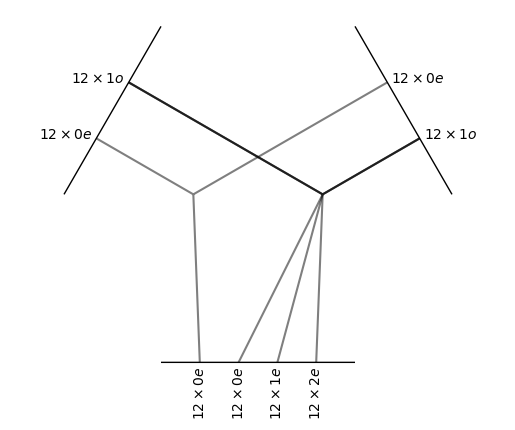

In [21]:
i_in1 = o3.Irreps('1x0e + 1x1o + 1x2e')
i_in1 = o3.Irreps('12x0e + 12x1o')
tp = o3.ElementwiseTensorProduct(i_in1,i_in1)
i_in2 = tp.irreps_out.simplify()

i_out = o3.Irreps('1x0o')
print(i_in1), print(i_in2), print(i_out)
print(tp)

tp.visualize()


/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


TensorProduct(12x0e+12x1o x 24x0e+12x1e+12x2e -> 12x0o | 144 paths | 144 weights)

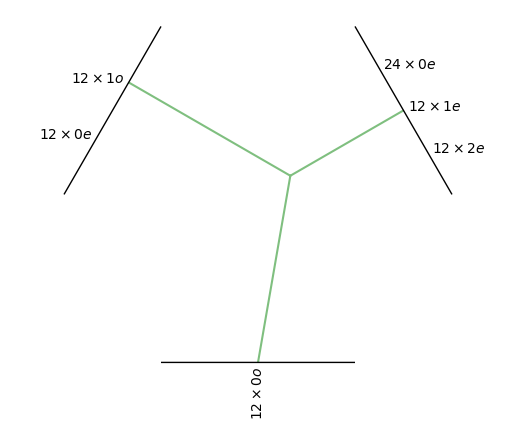

In [22]:
irreps_mid, instructions = tp_out_irreps_with_instructions(
            i_in1 , i_in2, i_out,
        )
conv_tp = o3.TensorProduct(
    i_in1, i_in2,
    irreps_mid,
    instructions=instructions,
    shared_weights=False,
    internal_weights=False,
    # cueq_config=self.cueq_config,
)
conv_tp.visualize()
conv_tp

# Test on example

```python
fname = '/home/lls34/rds/hpc-work/GitHub/Mace-Mol-Des/mol.xyz'
fname = 'Conformer3D_COMPOUND_CID_5426.sdf'
at = read(fname)
```

In [23]:
symbols = ["C", "Cl", "Br", "I", "H"]
positions = [
    [-0.056722058963768,  0.042901511925388,  0.162540724033739],
    [-0.531381967093891,  1.609025894813493, -0.532575055118152],
    [-1.232866700121787, -1.340225722460375, -0.502142399221806],
    [ 1.951815787763955, -0.403138388011898, -0.396222161046241],
    [-0.130845061584506,  0.091436703733396,  1.268398891352458]
]
at= Atoms(symbols=symbols, positions=positions)
at.rattle(0.1)


In [24]:
at2 = at.copy()
pos = at2.get_positions()
pos *= -1 
at2.set_positions(pos)

In [25]:
des1 = torch.tensor(calc.get_descriptors(at, invariants_only=False)[:,:-128])*10
des2 = torch.tensor(calc.get_descriptors(at2, invariants_only=False)[:,:-128])*10

des1.shape, 128 *4, 128*9

(torch.Size([5, 512]), 512, 1152)

In [26]:
#  Invariant features are identical
torch.sum(torch.abs(des1[0,:128] - des2[0,:128])), torch.mean(torch.abs(des1-des2))

(tensor(0.), tensor(0.2224))

# TP Option 1

In [43]:
i_in1 = o3.Irreps('128x0e + 128x1o')

tp_1 = o3.TensorProduct(
    i_in1, i_in1,
    o3.Irreps('128x1e'),
    instructions = [(1, 1, 0, 'uvu', True)],
    shared_weights=True,
    internal_weights=True,
)
# tp_1 = o3.FullTensorProduct(i_in1, i_in1)

lin = o3.Linear(
    tp_1.irreps_out, '10x1e'
)
irreps_mid, instructions = tp_out_irreps_with_instructions(
            i_in1, lin.irreps_out,
    o3.Irreps('1x0o'),
        )
tp_2 = o3.TensorProduct(
    i_in1, lin.irreps_out,
    irreps_mid,
    instructions=instructions,
    shared_weights=True,
    internal_weights=True,
)
print(tp_1)
print(lin)
print(tp_2)

TensorProduct(128x0e+128x1o x 128x0e+128x1o -> 128x1e | 16384 paths | 16384 weights)
Linear(128x1e -> 10x1e | 1280 weights)
TensorProduct(128x0e+128x1o x 10x1e -> 128x0o | 1280 paths | 1280 weights)


/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


In [44]:
out1 = tp_2(des1[:],lin(tp_1(des1[:], des1[:])) )
out2 = tp_2(des2[:],lin(tp_1(des2[:], des2[:])) )
torch.mean(torch.abs(out1)), torch.mean(torch.abs(out1-out2))

(tensor(0.0012, grad_fn=<MeanBackward0>),
 tensor(0.0025, grad_fn=<MeanBackward0>))

In [45]:
tp_1, lin, tp_2

(TensorProduct(128x0e+128x1o x 128x0e+128x1o -> 128x1e | 16384 paths | 16384 weights),
 Linear(128x1e -> 10x1e | 1280 weights),
 TensorProduct(128x0e+128x1o x 10x1e -> 128x0o | 1280 paths | 1280 weights))

# TP option 2

In [68]:

i_in1 = o3.Irreps('128x0e + 128x1o')
embedd_irrep1 = o3.Irreps('10x1o')
embedd_irrep2 = o3.Irreps('10x1e')


lin0 = o3.Linear(i_in1, embedd_irrep1)
tp_1 = o3.TensorProduct(
    i_in1, embedd_irrep1,
    o3.Irreps('128x1e'),
    instructions = [(1, 0, 0, 'uvu', True)],
    shared_weights=True,
    internal_weights=True,
)
# tp_1 = o3.FullTensorProduct(i_in1, i_in1)

lin = o3.Linear(
    tp_1.irreps_out, embedd_irrep2
)
irreps_mid, instructions = tp_out_irreps_with_instructions(
            i_in1, lin.irreps_out,
    o3.Irreps('1x0o'),
        )
tp_2 = o3.TensorProduct(
    i_in1, lin.irreps_out,
    irreps_mid,
    instructions=instructions,
    shared_weights=True,
    internal_weights=True,
)
print(lin0)
print(tp_1)
print(lin)
print(tp_2)

out1 = tp_2(des1[:],lin(tp_1(des1[:], lin0(des1[:]))) )
out2 = tp_2(des2[:],lin(tp_1(des2[:], lin0(des2[:]))) )
torch.mean(torch.abs(out1)), torch.mean(torch.abs(out1-out2))



Linear(128x0e+128x1o -> 10x1o | 1280 weights)
TensorProduct(128x0e+128x1o x 10x1o -> 128x1e | 1280 paths | 1280 weights)
Linear(128x1e -> 10x1e | 1280 weights)
TensorProduct(128x0e+128x1o x 10x1e -> 128x0o | 1280 paths | 1280 weights)


/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/Users/lars/miniforge3/envs/mace/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/

(tensor(0.0012, grad_fn=<MeanBackward0>),
 tensor(0.0023, grad_fn=<MeanBackward0>))